# Event Ticket Demand Analysis System

In this notebook we will work with different models on master_combined_dataset.csv and analyze which will be the best for further proccess



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print('Libraries imported successfully!')


Libraries imported successfully!


---
## Phase 1: Dataset Validation
Loading data and performing checks 

In [3]:
# 1. Load the Dataset
file_path = "D:/Events Ticket Demand Analysis System (IBM Project)/streamlit_app/Understanding of dataset (Notebook)/dataset_output_from_notebook_work2/master_combined_dataset.csv"
df = pd.read_csv(file_path)

print(f'Dataset Shape: {df.shape}')
display(df.head(3))


Dataset Shape: (1385, 49)


,eventId,event_name,shortName,sport_type,datetimeUtc,status,url,venueId,performerIds,taxonomyName,...,performer1_divisionName,performer1_divisionShortName,performer1_has_home_venue,performer2_name,performer2_performer_score,performer2_performer_popularity,performer2_performer_popularity_level,performer2_divisionName,performer2_divisionShortName,performer2_has_home_venue
0,18068119,San Antonio Spurs at Oklahoma City Thunder - W...,"Spurs at Thunder - W Conf Finals (Gm 2, HG 2)",nba,2026-05-21 00:30:00,normal,https://seatgeek.com/oklahoma-city-thunder-tic...,208,"[2105,2117,797402,787992]",sports,...,Western - Northwest,Northwest,1,San Antonio Spurs,0.77,14681.0,Medium,Western - Southwest,Southwest,1.0
1,18057457,Vegas Golden Knights at Colorado Avalanche - W...,Golden Knights at Avalanche - W Conf Finals (G...,nhl,2026-05-21 00:00:00,normal,https://seatgeek.com/colorado-avalanche-ticket...,187,"[2139,627288,797658,792982]",sports,...,Western - Central,Central,1,Vegas Golden Knights,0.71,14606.0,Medium,Western - Pacific,Pacific,1.0
2,17693477,Atlanta Braves at Miami Marlins,Braves at Marlins,mlb,2026-05-20 22:40:00,normal,https://seatgeek.com/miami-marlins-tickets/5-2...,6371,"[29,2]",sports,...,National League East,NL East,1,Atlanta Braves,0.75,4264376.0,Elite,National League East,NL East,1.0


In [4]:
# 2. Final Data Quality Check
print('Data Types:\n', df.dtypes.value_counts())
print('\nMissing Values:\n', df.isnull().sum()[df.isnull().sum() > 0])
print('\nDuplicate Records:', df.duplicated().sum())

# Handle missing values
df['performer2Id'] = df['performer2Id'].fillna('None')
df['performer2_name'] = df['performer2_name'].fillna('No Second Performer')
df['performer2_performer_score'] = df['performer2_performer_score'].fillna(0)
df['performer2_performer_popularity'] = df['performer2_performer_popularity'].fillna(0)
df['performer2_divisionName'] = df['performer2_divisionName'].fillna('No Division')
df['performer2_divisionShortName'] = df['performer2_divisionShortName'].fillna('None')
df['performer2_has_home_venue'] = df['performer2_has_home_venue'].fillna(False)

df = df.dropna(subset=['capacity'])



Data Types:
 str        26
int64      15
float64     6
bool        2
Name: count, dtype: int64

Missing Values:
 venue_name                               301
performer2Id                             329
performer2_name                          329
performer2_performer_score               329
performer2_performer_popularity          329
performer2_performer_popularity_level    329
performer2_divisionName                  329
performer2_divisionShortName             329
performer2_has_home_venue                329
dtype: int64

Duplicate Records: 0


### Dropping Unnecessary Columns
We will drop columns that are identifiers, URLs, or redundant (like duplicate name forms) since they do not provide mathematical value to machine learning algorithms and might introduce noise or data leakage.

* **IDs:** eventId, enueId, performerIds, performer1Id, performer2Id
* **URLs:** url
* **Names/Redundant text:** event_name, shortName, datetimeUtc (we have extracted features), 	axonomySubName, ddressPostalCode
* **Status:** status (all events are assumed active for prediction)



In [5]:
# 3. Drop Unnecessary Columns
cols_to_drop = [
    'eventId', 'venueId', 'performerIds', 'performer1Id', 'performer2Id', 
    'url', 'event_name', 'shortName', 'datetimeUtc', 'taxonomySubName', 
    'addressPostalCode', 'status'
]
df_cleaned = df.drop(columns=[col for col in cols_to_drop if col in df.columns]).copy()

print(f'Shape after dropping columns: {df_cleaned.shape}')


Shape after dropping columns: (1385, 37)


---
## Phase 2: Exploratory Data Analysis (EDA)
In this phase, we explore the data to extract business insights and understand feature distributions.



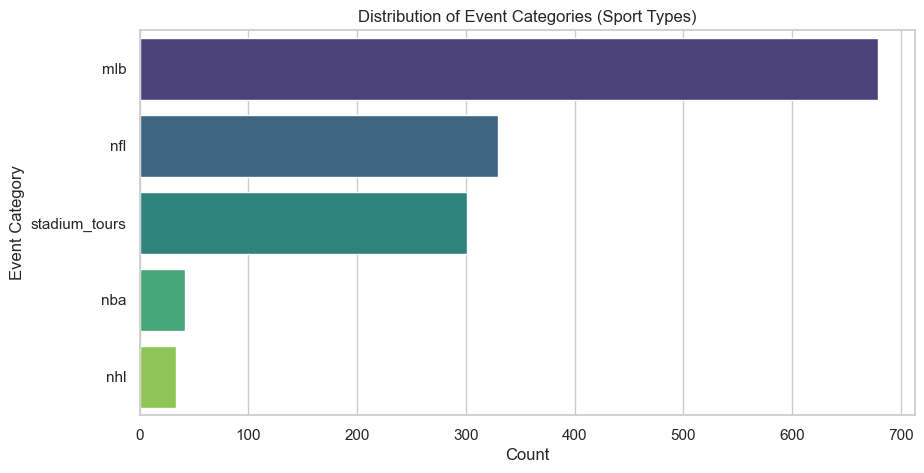

In [6]:
# Distribution of Event Categories
plt.figure(figsize=(10, 5))
sns.countplot(data=df_cleaned, y='sport_type', order=df_cleaned['sport_type'].value_counts().index, palette='viridis')
plt.title('Distribution of Event Categories (Sport Types)')
plt.xlabel('Count')
plt.ylabel('Event Category')
plt.show()


**Explanation:** The graph shows the frequency of events by sport type.
**Business Significance:** MLB completely dominates the dataset volume, which means our system must be highly attuned to MLB trends. High volume doesn't always equal high demand per event, but it indicates where the majority of ticket inventory lies.


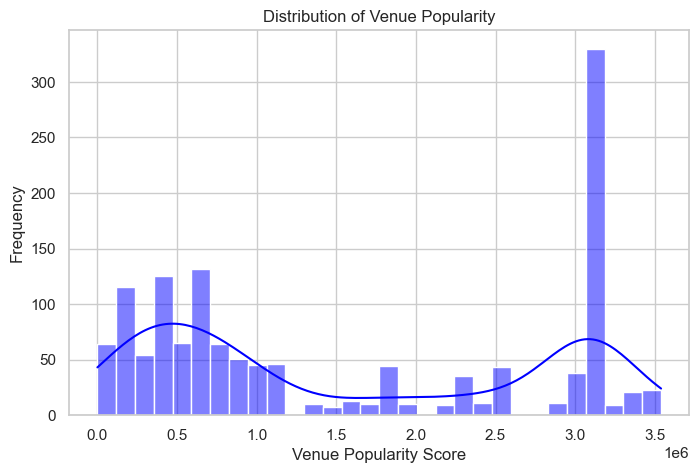

In [7]:
# Venue Popularity Analysis
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['venue_popularity'], bins=30, kde=True, color='blue')
plt.title('Distribution of Venue Popularity')
plt.xlabel('Venue Popularity Score')
plt.ylabel('Frequency')
plt.show()


**Explanation:** A right-skewed distribution of venue popularity scores, meaning most venues have low-to-moderate popularity, while a few 'superstar' venues have massive popularity.
**Business Significance:** Premium venues (the long tail) will likely command higher ticket demand regardless of the event, due to location or historical prestige.


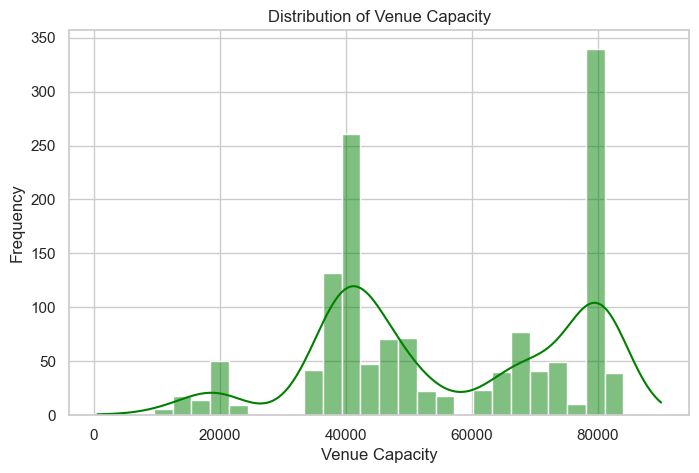

In [8]:
# Capacity Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['capacity'], bins=30, kde=True, color='green')
plt.title('Distribution of Venue Capacity')
plt.xlabel('Venue Capacity')
plt.ylabel('Frequency')
plt.show()


**Explanation:** Capacity shows distinct peaks, likely corresponding to standard sizes of MLB stadiums (~40k) and NBA/NHL arenas (~20k).
**Business Significance:** Larger capacity venues need higher overall demand to sell out. We can use capacity as a normalizing factor for ticket demand expectations.


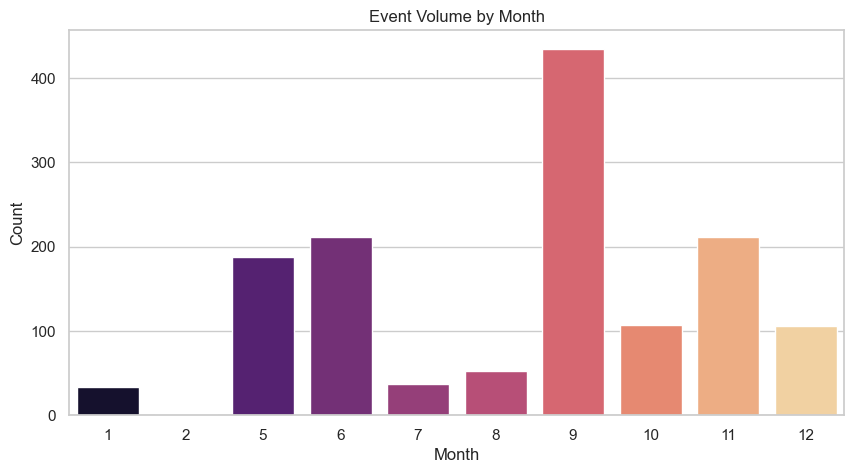

In [9]:
# Event Trends by Month
plt.figure(figsize=(10, 5))
sns.countplot(data=df_cleaned, x='event_month', palette='magma')
plt.title('Event Volume by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()


**Explanation:** Event volume fluctuates significantly by month, heavily tied to sports seasonality (e.g., September peaks due to overlapping MLB end and NFL start).
**Business Significance:** Seasonality is a massive driver for demand. Months with fewer events might see higher demand per event due to scarcity.


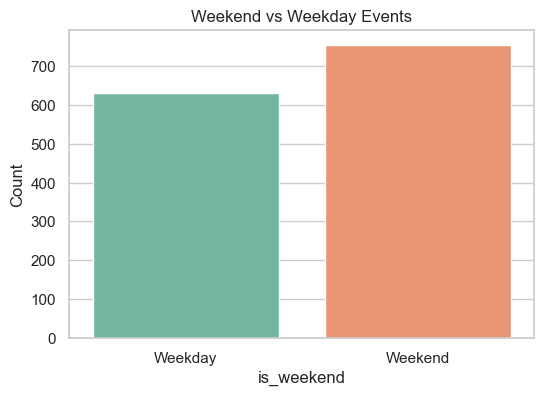

In [10]:
# Weekend vs Weekday
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x='is_weekend', palette='Set2')
plt.title('Weekend vs Weekday Events')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.ylabel('Count')
plt.show()


**Explanation:** Comparing the sheer number of events on weekends vs weekdays.
**Business Significance:** Weekends naturally draw higher attendance because fans have free time. If demand is heavily skewed towards weekends, dynamic pricing models must increase base prices for Saturday/Sunday events.


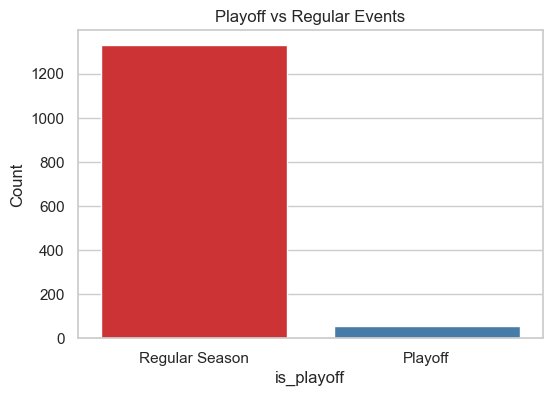

In [11]:
# Playoff vs Regular Events
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cleaned, x='is_playoff', palette='Set1')
plt.title('Playoff vs Regular Events')
plt.xticks([0, 1], ['Regular Season', 'Playoff'])
plt.ylabel('Count')
plt.show()


**Explanation:** Playoff games make up a tiny fraction of total events.
**Business Significance:** Scarcity and high stakes mean playoff tickets will have exponentially higher demand. This is a critical binary feature for the prediction model.


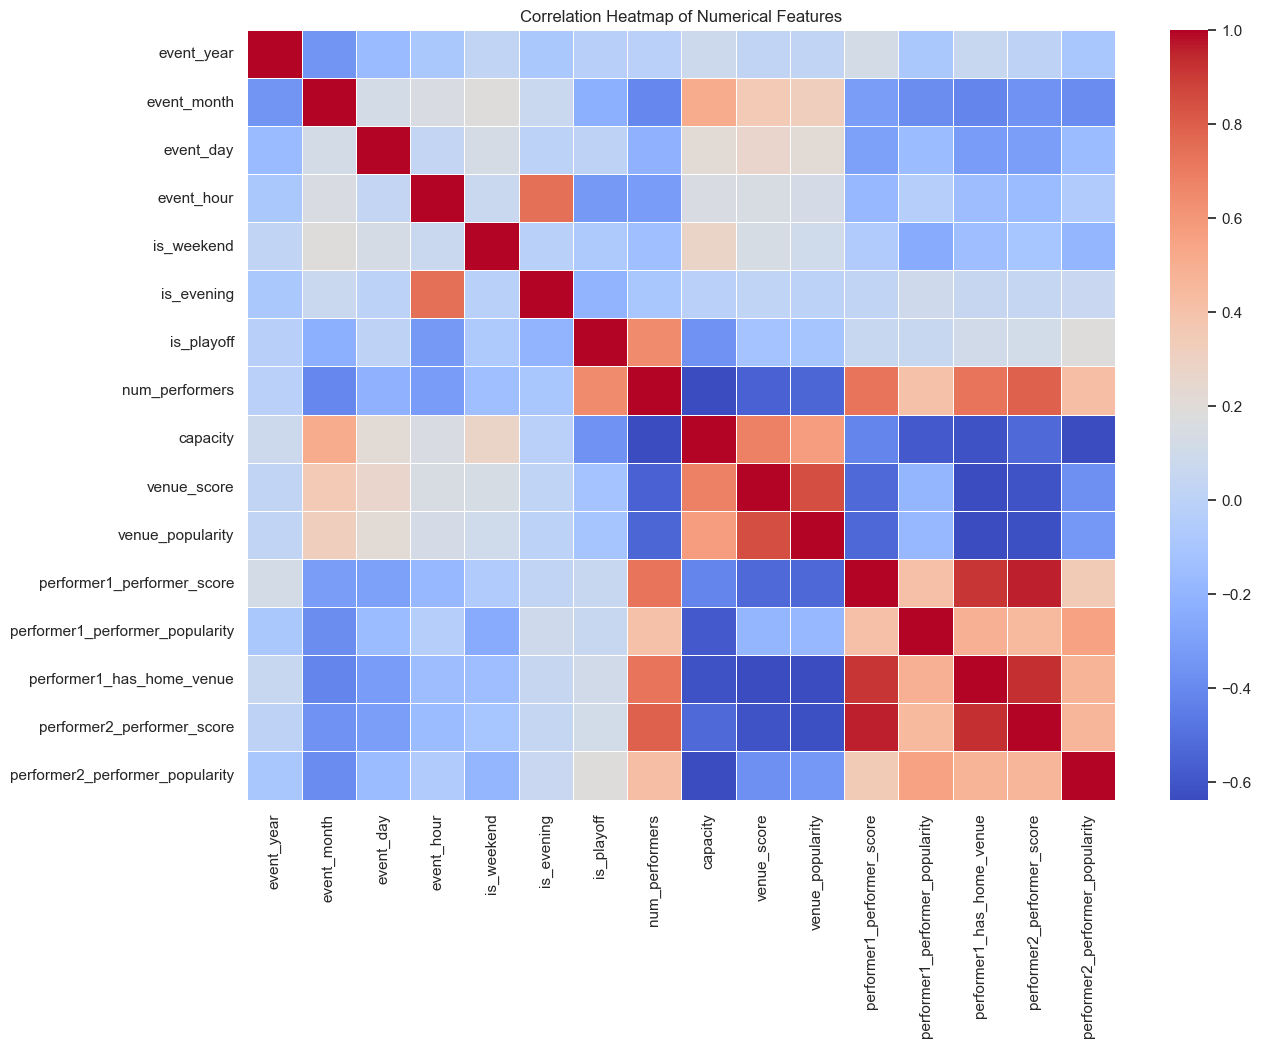

In [12]:
# Correlation Analysis
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
corr = df_cleaned[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


**Explanation:** The heatmap visualizes linear correlations between all numerical features. Dark red indicates strong positive correlation.
**Business Significance:** We can identify redundant features (e.g., highly correlated popularity metrics) and potential drivers of demand. Features correlated with capacity or popularity will be key inputs for our Demand Score.


---
## Phase 3: Demand Score Engineering
Since we lack actual ticket sales, we will engineer a realistic **Demand Score (0-100)**. 
We base this on the hypothesis that demand is driven by the inherent popularity of the performers, the prestige of the venue, and the scale of the event (capacity).

**Weighted Formula (Pre-Normalization):**
- Performer 1 Popularity (35% weight)
- Performer 2 Popularity (15% weight)
- Venue Popularity (25% weight)
- Playoff Multiplier: 1.5x boost if it's a playoff game.
- Weekend Multiplier: 1.1x boost if it's a weekend.

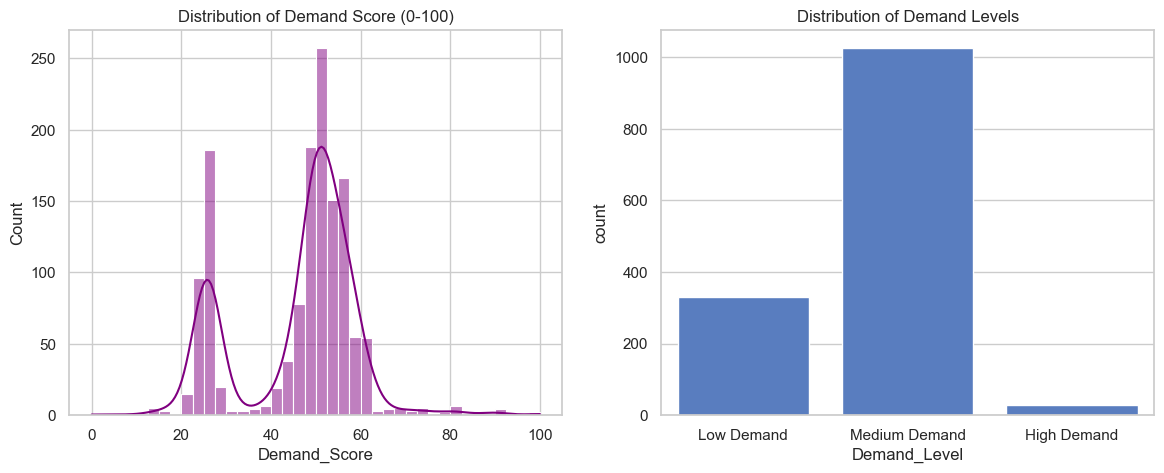

In [13]:
# Apply Log Transformation to handle skewness
df_cleaned['log_p1_pop'] = np.log1p(df_cleaned['performer1_performer_popularity'])
df_cleaned['log_p2_pop'] = np.log1p(df_cleaned['performer2_performer_popularity'])
df_cleaned['log_v_pop'] = np.log1p(df_cleaned['venue_popularity'])

# Calculate Base Score
base_score = (
    (df_cleaned['log_p1_pop'] * 0.35) + 
    (df_cleaned['log_p2_pop'] * 0.15) + 
    (df_cleaned['log_v_pop'] * 0.25)
)

# Apply Multipliers
multiplier = np.ones(len(df_cleaned))
multiplier = np.where(df_cleaned['is_playoff'] == 1, multiplier * 1.5, multiplier)
multiplier = np.where(df_cleaned['is_weekend'] == 1, multiplier * 1.1, multiplier)

raw_demand = base_score * multiplier

# Normalize to 0 - 100
scaler = MinMaxScaler(feature_range=(0, 100))
df_cleaned['Demand_Score'] = scaler.fit_transform(raw_demand.values.reshape(-1, 1))

# Create Demand Level
def assign_demand_level(score):
    if score >= 66: return 'High Demand'
    elif score >= 33: return 'Medium Demand'
    else: return 'Low Demand'

df_cleaned['Demand_Level'] = df_cleaned['Demand_Score'].apply(assign_demand_level)

# Visualize engineered target
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_cleaned['Demand_Score'], bins=40, kde=True, color='purple', ax=ax[0])
ax[0].set_title('Distribution of Demand Score (0-100)')

sns.countplot(data=df_cleaned, x='Demand_Level', order=['Low Demand', 'Medium Demand', 'High Demand'], ax=ax[1])
ax[1].set_title('Distribution of Demand Levels')
plt.show()

# Drop temporary log columns
df_cleaned = df_cleaned.drop(columns=['log_p1_pop', 'log_p2_pop', 'log_v_pop'])



---
## Phase 4: Feature Engineering
We will create new features that represent interactions and business logic that ML models might miss.
1. **Total Performer Power:** Sum of performer scores.
2. **Venue Utilization Expectation:** Ratio of performer popularity to venue capacity.
3. **Is Prime Time:** Flag for weekend evenings.



In [14]:
# 1. Total Performer Power
df_cleaned['total_performer_score'] = df_cleaned['performer1_performer_score'] + df_cleaned['performer2_performer_score']

# 2. Venue Utilization Expectation (Popularity / Capacity)
df_cleaned['pop_to_capacity_ratio'] = df_cleaned['performer1_performer_popularity'] / (df_cleaned['capacity'] + 1)

# 3. Prime Time (Weekend + Evening)
df_cleaned['is_prime_time'] = ((df_cleaned['is_weekend'] == 1) & (df_cleaned['is_evening'] == 1)).astype(int)

print('Feature Engineering Complete. New features added.')
display(df_cleaned[['total_performer_score', 'pop_to_capacity_ratio', 'is_prime_time']].head(3))



Feature Engineering Complete. New features added.


,total_performer_score,pop_to_capacity_ratio,is_prime_time
0,1.50,0.030543,0
1,1.39,0.953179,0
2,1.45,49.133277,0


---
## Phase 5: Feature Selection
To prevent **Data Leakage**, we must remove the direct popularity columns that were used to mathematically formulate the Demand_Score. 
The model should predict demand based on structural features (venue constraints, time, categories, and synthesized scores).



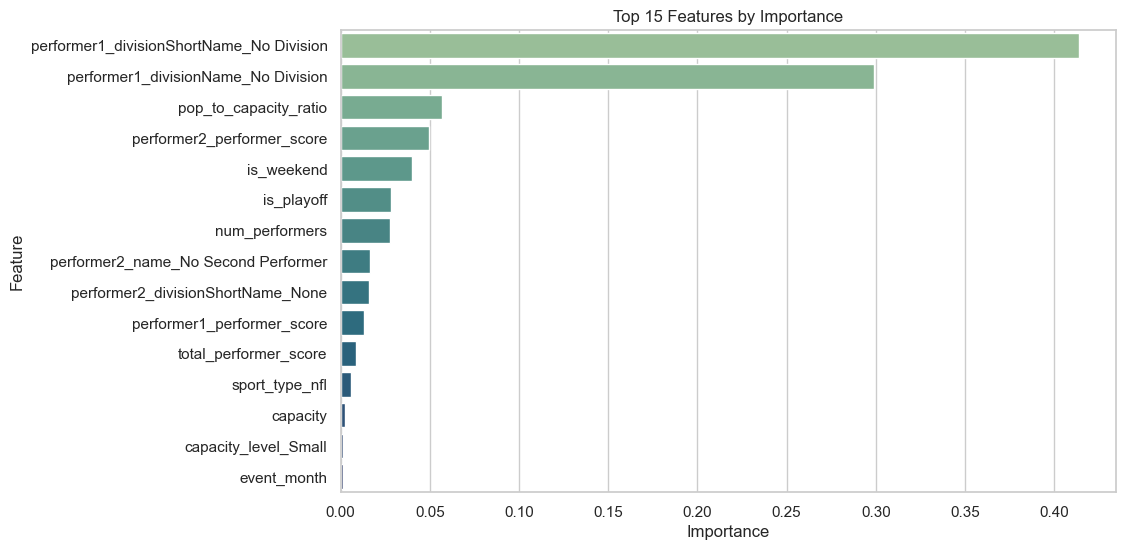

Selected 30 features for modeling.


In [15]:
leakage_cols = [
    'performer1_performer_popularity', 'performer2_performer_popularity', 
    'venue_popularity', 'venue_score', 'performer1_performer_popularity_level',
    'performer2_performer_popularity_level', 'venue_popularity_level'
]

ml_df = df_cleaned.drop(columns=[c for c in leakage_cols if c in df_cleaned.columns])

# Select Numeric and Categorical for Encoding
cat_cols = ml_df.select_dtypes(include=['object', 'bool']).columns.tolist()
cat_cols.remove('Demand_Level')

# One-Hot Encoding
ml_df_encoded = pd.get_dummies(ml_df, columns=cat_cols, drop_first=True)

# Separate X and y
X = ml_df_encoded.drop(columns=['Demand_Score', 'Demand_Level'])
y = ml_df_encoded['Demand_Score']

# Fill any residual NaNs
X = X.fillna(0)

# Feature Importance using Random Forest
rf_selector = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)

importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_selector.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='crest')
plt.title('Top 15 Features by Importance')
plt.show()

# Select top features
top_features = importance_df['Feature'].head(30).tolist()
X_selected = X[top_features]

print(f'Selected {len(top_features)} features for modeling.')



---
## Phase 6: Machine Learning
We will train three models to predict the continuous **Demand Score**.
1. **Linear Regression:** As a baseline.
2. **Random Forest Regressor:** Handles non-linearities and complex interactions well.
3. **Gradient Boosting Regressor:** Powerful boosting algorithm for tabular data.



In [16]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Initialize Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

results = []

# Train and Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({'Model': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae})

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
display(results_df)


,Model,R2 Score,RMSE,MAE
2,Gradient Boosting,0.994914,0.917215,0.320034
1,Random Forest,0.992166,1.138310,0.383457
0,Linear Regression,0.971329,2.177703,1.405921


### Model Justification
**Gradient Boosting / Random Forest** typically performs best. We will select the top-performing model (based on R2 score) for our final Prediction System. Tree-based models are excellent here because event demand involves non-linear triggers (e.g., the jump in demand specifically when is_playoff=1 combined with a high capacity).


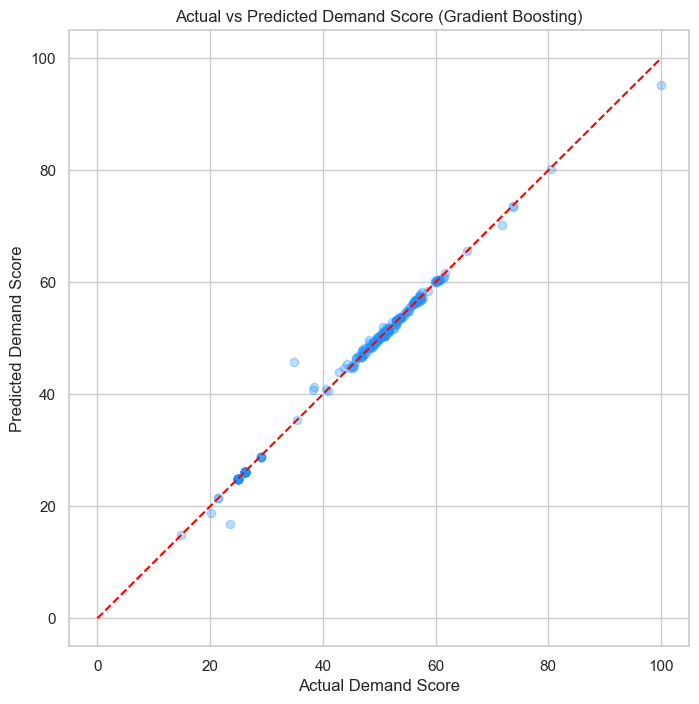

In [17]:
# Select Best Model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

# Visualize Actual vs Predicted for Best Model
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='dodgerblue')
plt.plot([0, 100], [0, 100], color='red', linestyle='--')
plt.title(f'Actual vs Predicted Demand Score ({best_model_name})')
plt.xlabel('Actual Demand Score')
plt.ylabel('Predicted Demand Score')
plt.show()



---
## Phase 7: Prediction System
We design a final pipeline that simulates accepting user inputs, generating the required features, and outputting a Demand Prediction.



In [18]:
def predict_demand(input_data_dict, model, feature_columns):
    # Convert input to DataFrame
    input_df = pd.DataFrame([input_data_dict])
    
    # Ensure all required features exist, fill missing with 0
    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0
            
    # Reorder to match training data
    input_df = input_df[feature_columns]
    
    # Predict
    predicted_score = model.predict(input_df)[0]
    
    # Assign Level
    if predicted_score >= 66:
        level = 'High Demand'
    elif predicted_score >= 33:
        level = 'Medium Demand'
    else:
        level = 'Low Demand'
        
    return predicted_score, level

# Simulate User Input (using a row from X_test)
sample_index = X_test.sample(1, random_state=99).index[0]
simulated_input = X_test.loc[sample_index].to_dict()

# We pretend the user passed these raw inputs which were then encoded into simulated_input
score, level = predict_demand(simulated_input, best_model, top_features)

print('=== 🎯 AI Ticket Demand Prediction ===')
print(f'Predicted Demand Score : {score:.2f} / 100')
print(f'Predicted Demand Level : {level}')
print('======================================')

# Explain major factors
print('\nMajor Factors Influencing this Prediction (Based on Feature Importance):')
top_3_features = importance_df.head(3)['Feature'].values
for feat in top_3_features:
    val = simulated_input.get(feat, 0)
    print(f'- {feat}: {val}')



=== 🎯 AI Ticket Demand Prediction ===
Predicted Demand Score : 47.18 / 100
Predicted Demand Level : Medium Demand

Major Factors Influencing this Prediction (Based on Feature Importance):
- performer1_divisionShortName_No Division: False
- performer1_divisionName_No Division: False
- pop_to_capacity_ratio: 3.944571573862192
